Overviewing of the Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/data.csv")

# Overview
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
Rows: 95662
Columns: 16

Column Names:
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

Data Types:
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
--

Summary Statistics

In [2]:
print("\nSummary Statistics (Numerical Columns):")
print(df.describe())

print("\nSummary Statistics (Including Categorical Columns):")
print(df.describe(include='all'))

# Additional insights
print("\nSkewness:")
print(df.skew(numeric_only=True))

print("\nKurtosis:")
print(df.kurt(numeric_only=True))


Summary Statistics (Numerical Columns):
       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000

Summary Statistics (Including Categorical Columns):
              TransactionId        BatchId       AccountId  \
count                 95662          95662           95662   
unique                95662          94809            3633   
top     Transactio

Distribution of Numerical Features

Histograms for all numerical columns

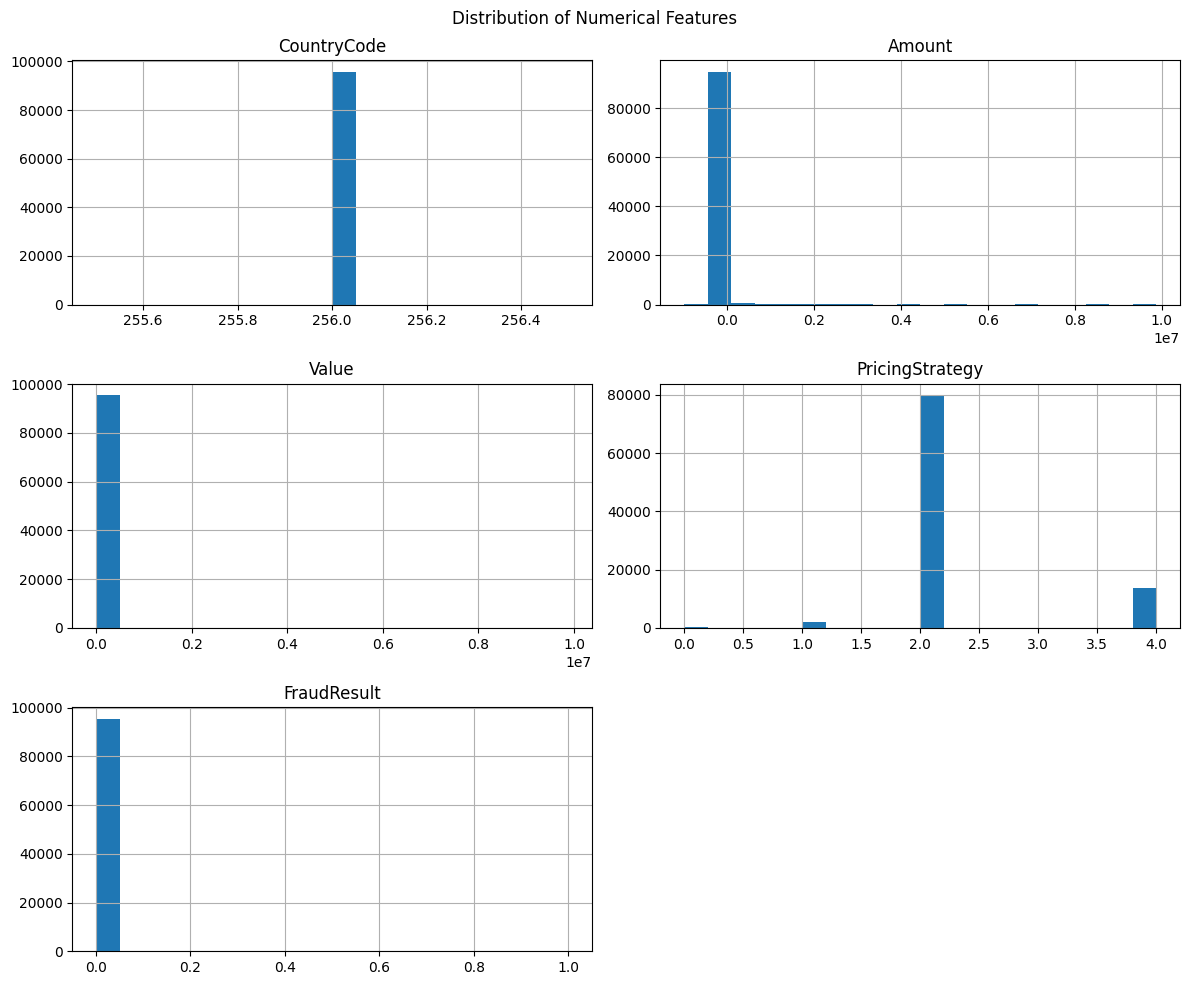

In [3]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[num_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

KDE plots (smoothed distribution curves)

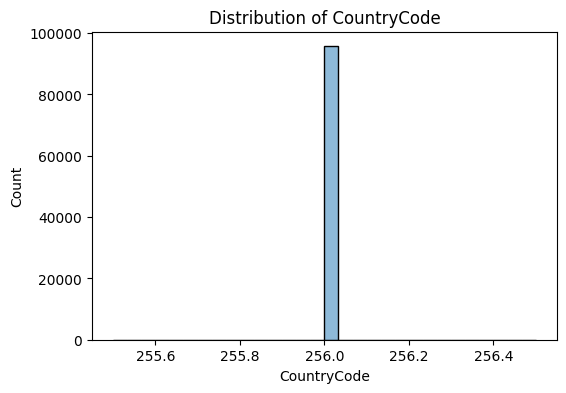

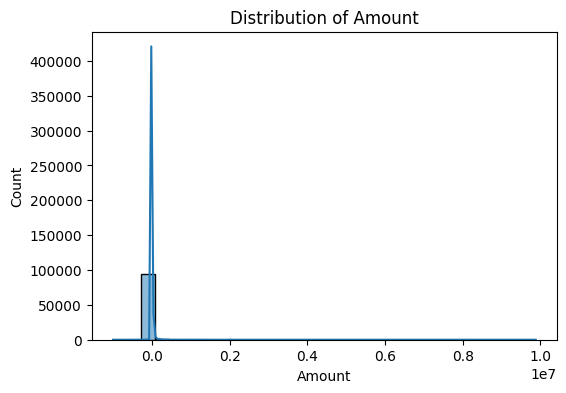

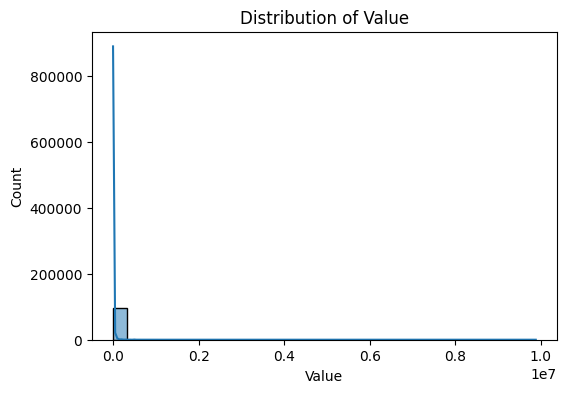

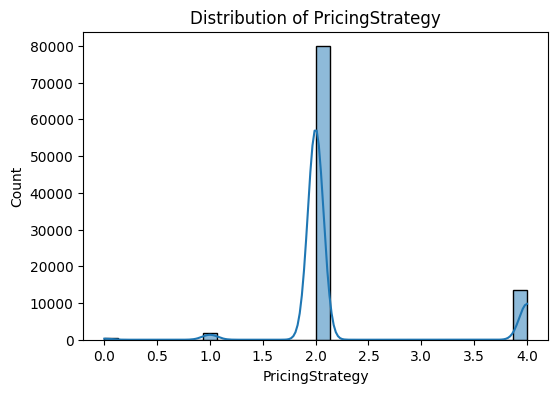

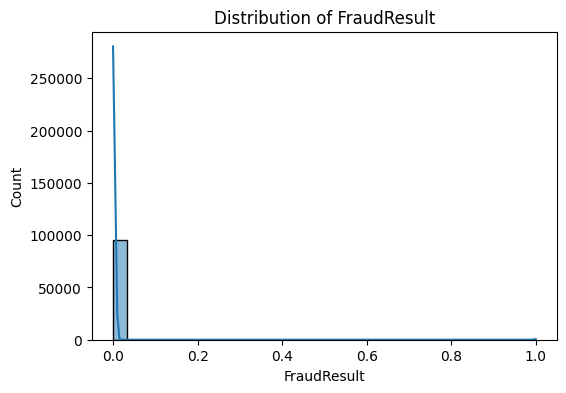

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

outliers detection using Boxplots 

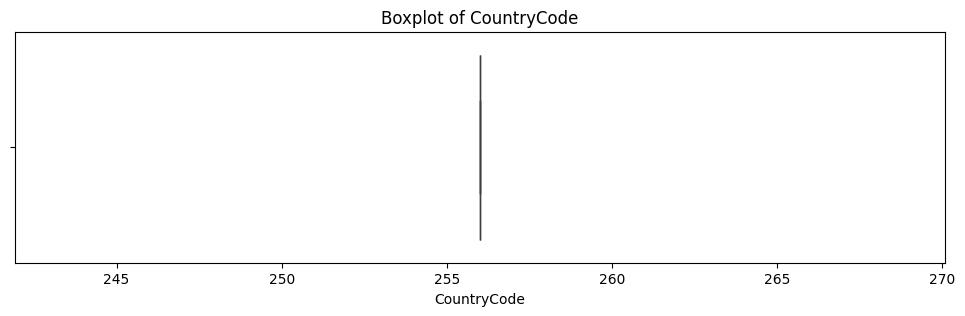

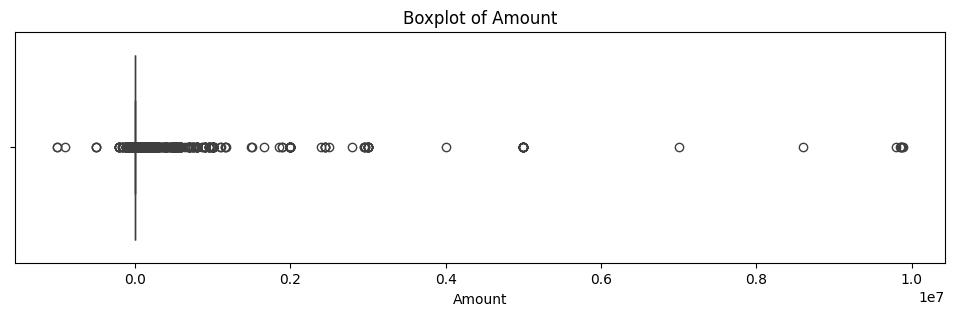

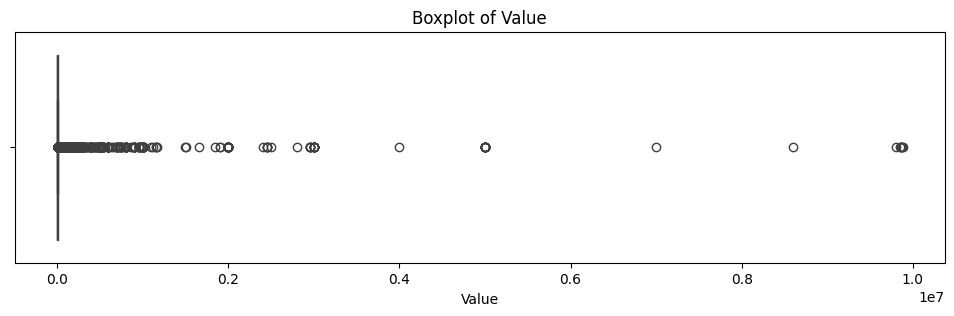

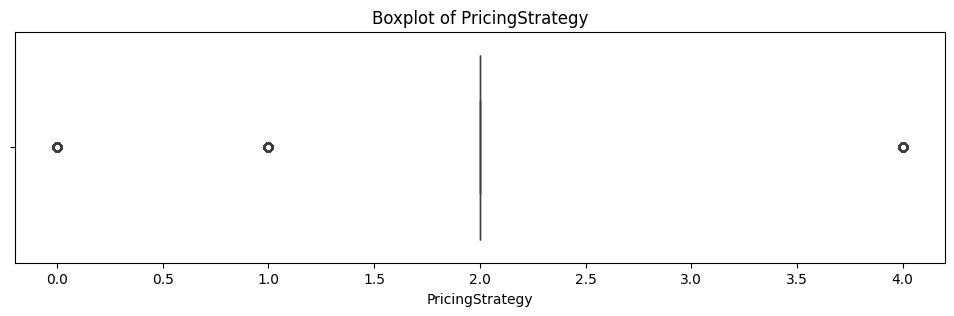

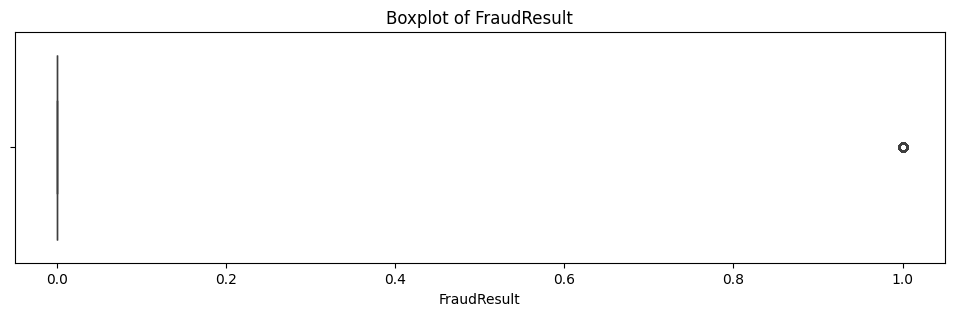

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Distribution of Categorical Features

In [18]:

# Select categorical columns
cat_cols = df.select_dtypes(include=['string' , 'category']).columns

# Frequency distribution for each categorical column
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())
    print("\nPercentage distribution:")
    print(df[col].value_counts(normalize=True) * 100)


Value counts for TransactionId:
TransactionId
TransactionId_76871     1
TransactionId_73770     1
TransactionId_26203     1
TransactionId_380       1
TransactionId_28195     1
                       ..
TransactionId_89881     1
TransactionId_91597     1
TransactionId_82501     1
TransactionId_136354    1
TransactionId_35670     1
Name: count, Length: 95662, dtype: int64

Percentage distribution:
TransactionId
TransactionId_76871     0.001045
TransactionId_73770     0.001045
TransactionId_26203     0.001045
TransactionId_380       0.001045
TransactionId_28195     0.001045
                          ...   
TransactionId_89881     0.001045
TransactionId_91597     0.001045
TransactionId_82501     0.001045
TransactionId_136354    0.001045
TransactionId_35670     0.001045
Name: proportion, Length: 95662, dtype: float64

Value counts for BatchId:
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
                  ..
BatchId_96668 

Top-N Categories (Useful for High-Cardinality Features)

In [19]:
N = 10  # top categories

for col in cat_cols:
    print(f"\nTop {N} categories in {col}:")
    print(df[col].value_counts().head(N))


Top 10 categories in TransactionId:
TransactionId
TransactionId_76871     1
TransactionId_73770     1
TransactionId_26203     1
TransactionId_380       1
TransactionId_28195     1
TransactionId_23223     1
TransactionId_118063    1
TransactionId_100640    1
TransactionId_51905     1
TransactionId_130161    1
Name: count, dtype: int64

Top 10 categories in BatchId:
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
BatchId_88001      9
BatchId_49408      7
BatchId_110084     7
BatchId_86880      6
BatchId_4233       6
Name: count, dtype: int64

Top 10 categories in AccountId:
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
AccountId_10        965
AccountId_3595      465
AccountId_751       411
AccountId_2648      359
AccountId_2314      356
Name: count, dtype: int64

Top 10 categories in SubscriptionId:
SubscriptionId
SubscriptionId_3829    326

Normalizing Bar Plot 

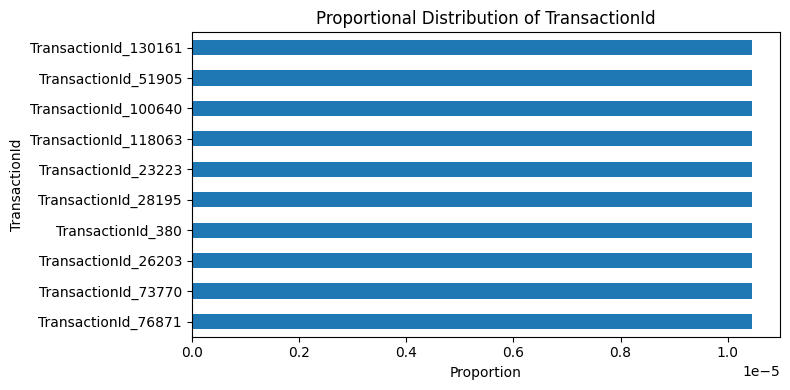

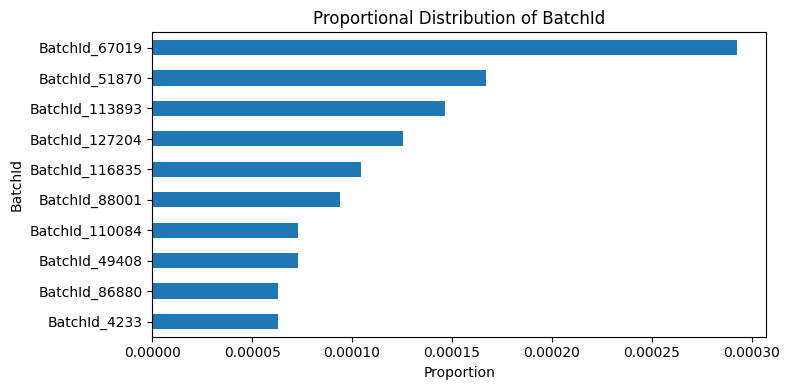

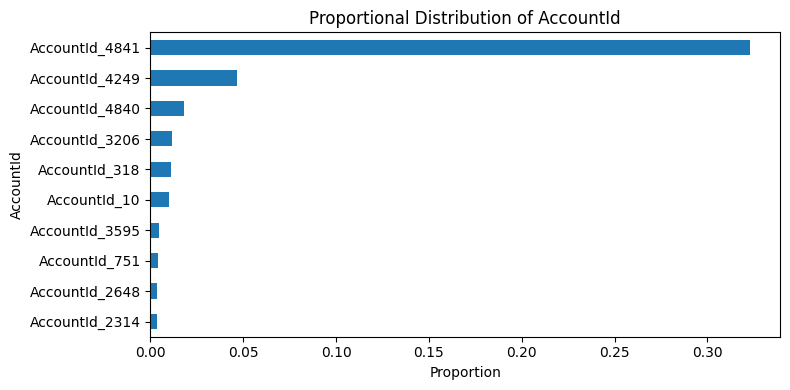

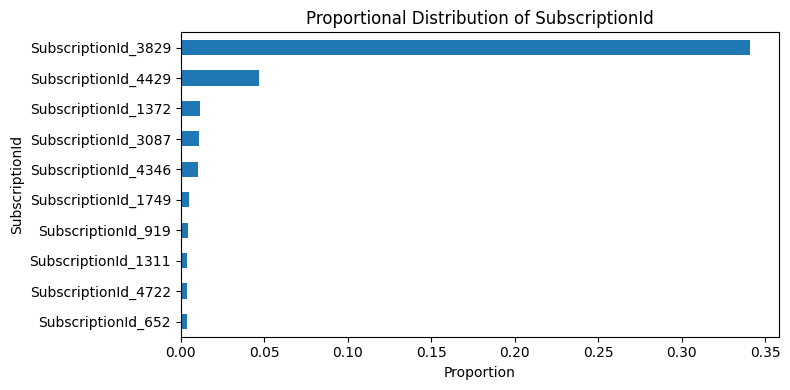

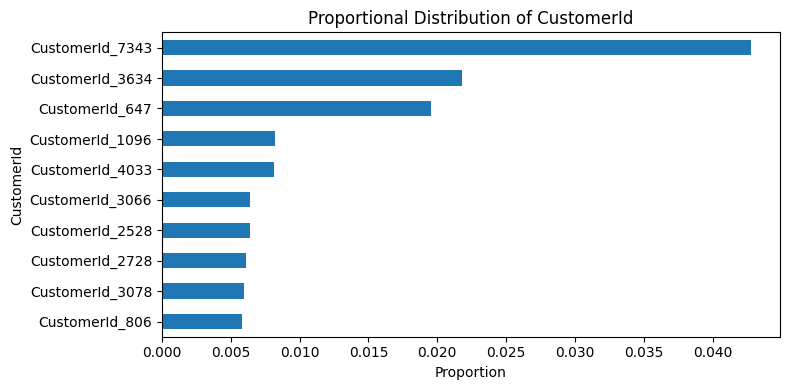

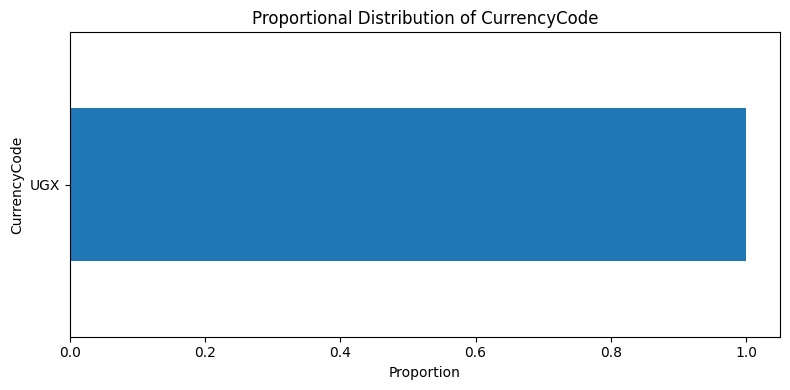

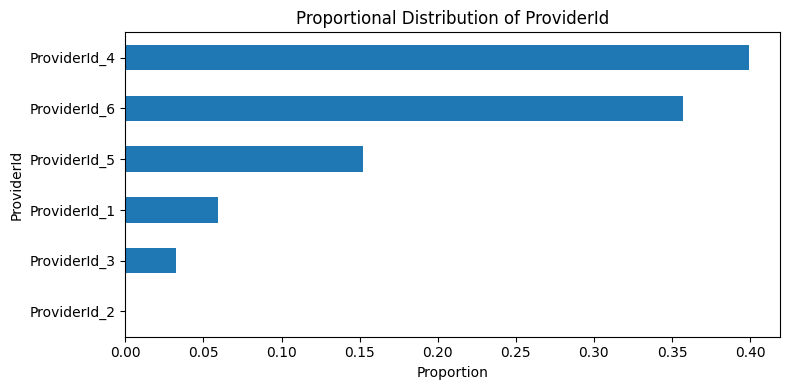

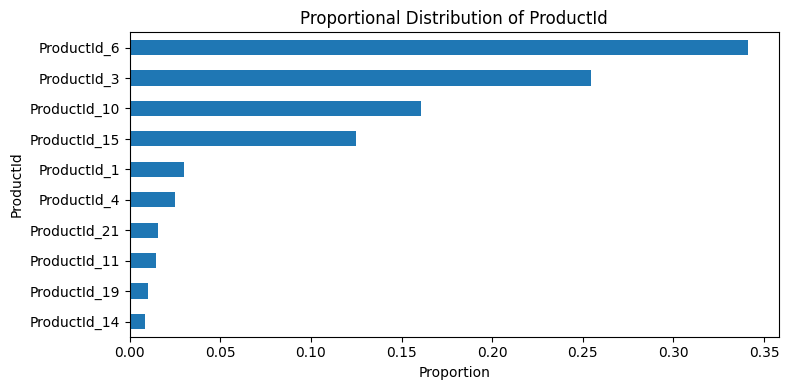

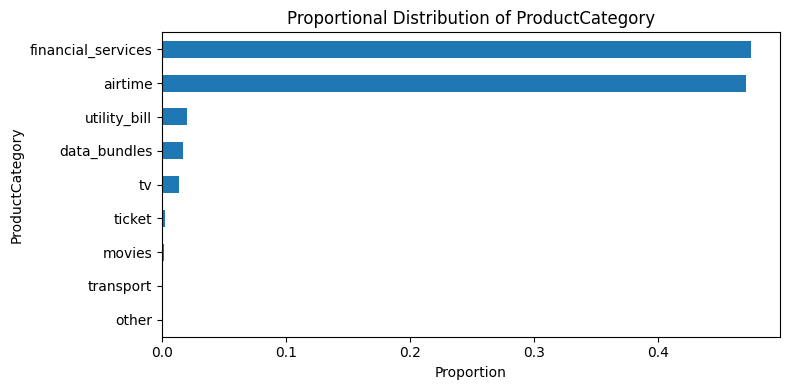

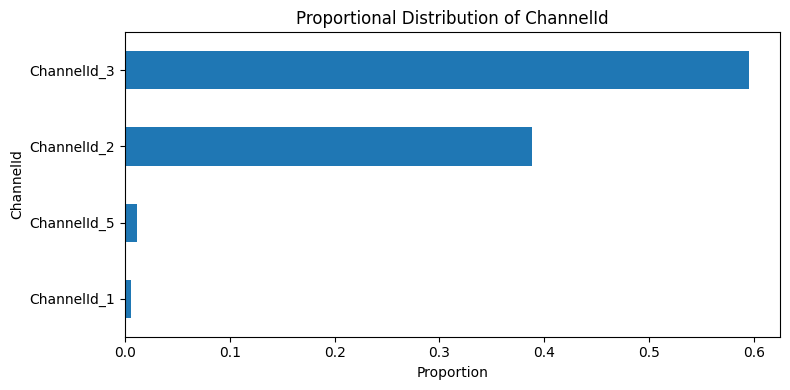

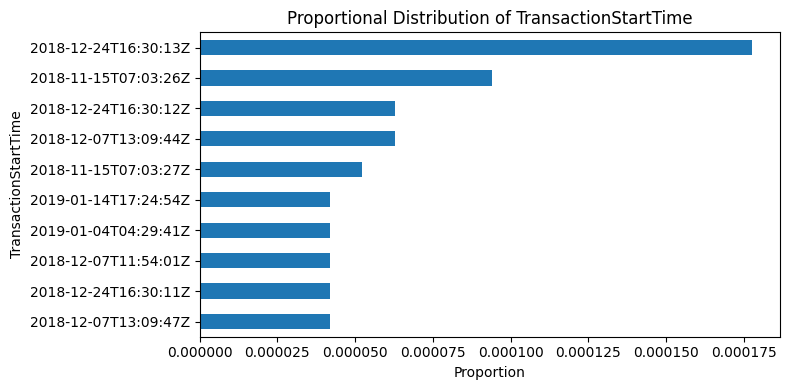

In [20]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    
    (df[col]
     .value_counts(normalize=True)
     .head(10)
     .sort_values()
     .plot(kind='barh'))
    
    plt.title(f"Proportional Distribution of {col}")
    plt.xlabel("Proportion")
    plt.tight_layout()
    plt.show()

correlation matrix(Understanding the relationship between numerical features)

In [21]:


# Select numerical columns only
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr()

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                 CountryCode    Amount     Value  PricingStrategy  FraudResult
CountryCode              NaN       NaN       NaN              NaN          NaN
Amount                   NaN  1.000000  0.989692        -0.061931     0.557370
Value                    NaN  0.989692  1.000000        -0.017020     0.566739
PricingStrategy          NaN -0.061931 -0.017020         1.000000    -0.033821
FraudResult              NaN  0.557370  0.566739        -0.033821     1.000000


Heatmap

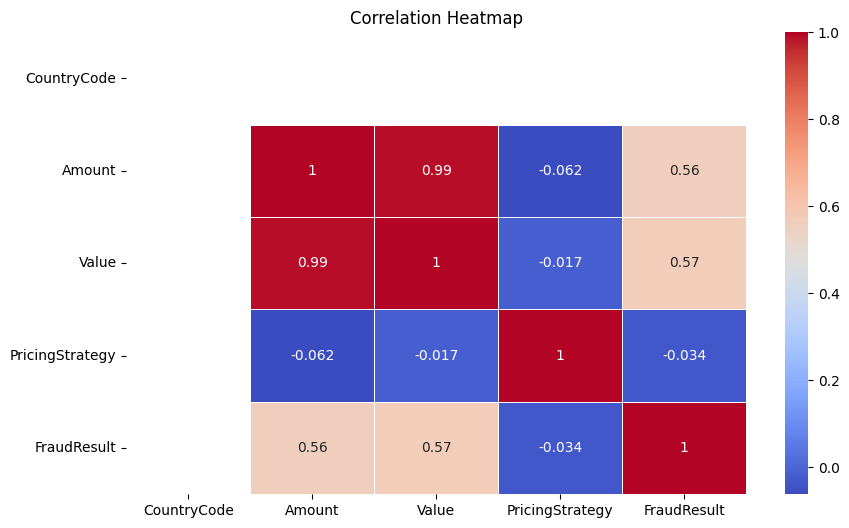

In [22]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

handling missing files

In [23]:
# Missing values count
missing_count = df.isnull().sum()

# Missing percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percent
})

print(missing_summary.sort_values(by="Missing Percentage", ascending=False))

                      Missing Values  Missing Percentage
TransactionId                      0                 0.0
BatchId                            0                 0.0
AccountId                          0                 0.0
SubscriptionId                     0                 0.0
CustomerId                         0                 0.0
CurrencyCode                       0                 0.0
CountryCode                        0                 0.0
ProviderId                         0                 0.0
ProductId                          0                 0.0
ProductCategory                    0                 0.0
ChannelId                          0                 0.0
Amount                             0                 0.0
Value                              0                 0.0
TransactionStartTime               0                 0.0
PricingStrategy                    0                 0.0
FraudResult                        0                 0.0


Identifing Outliers Using IQR Method

In [24]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

print("Number of outliers per feature:")
print(outlier_summary)

Number of outliers per feature:
{'CountryCode': 0, 'Amount': 24441, 'Value': 9021, 'PricingStrategy': 15814, 'FraudResult': 193}


Key EDA Insights & Modeling Implications
## 1. Feature distributions are skewed (especially financial variables)
Several numeric features (e.g., loan amount / income / balance-type fields) are heavily right-skewed.
A small number of extreme values dominate the distribution.

Impact on modeling:

Apply log1p or power transforms to reduce skewness.
Prefer models robust to non-normality (tree-based models handle this better).
Standard scaling alone is not enough.
## 2. Missing values are uniformly distributed
no missing value 
## 3. Certain features are strongly correlated
Some numeric features show high correlation (multicollinearity risk).
Redundant information exists between derived financial variables.

Impact on modeling:

Remove or combine highly correlated features.
Use regularized models (L1/L2 logistic regression).
Tree models are less sensitive but still benefit from reduced redundancy.
## 4. Class imbalance is present in the target variable
One class (e.g., “non-default”) dominates the dataset.

Impact on modeling:

Accuracy is not a reliable metric.
Use:
ROC-AUC
Precision/Recall
F1-score
Apply:
class weights (class_weight="balanced")
or resampling (SMOTE / undersampling)
## 5. Potential leakage risk in derived or post-event features
Some features may indirectly encode outcome information (e.g., repayment status, post-loan behavior).

Impact on modeling:

Carefully audit feature creation pipeline.
Remove any feature that is only known after the prediction time.
Ensure strict temporal separation between train/test if time-based data exists.